Inverse PINN: Identify $A$ and $Ea$ from multi-temperature **TGA** data


**Setup**: Generate synthetic TGA data at T = 600, 700, 800 K using $A_{true} = 5×10⁵, Ea_{true} = 60,000 J/mol$. Add noise $σ = 0.015$. Sample 15 points per temperature (45 total).


**What to identify**: Both A and Ea simultaneously as `dde.Variable` instances


**Initial guesses**: $A_{init} = 1×10⁵ , Ea_{init} = 40,000 J/mol $

**Key difficulty**: $A$ and $Ea$ differ by many orders of magnitude. Consider training on log(A) instead of A directly to stabilise training.


**What to report**: True vs recovered values and percentage error for both. Include a parity plot (predicted X vs observed X at all 3 temperatures).

Governing equation:

$$\frac{dX}{dt} = k(T) (1 - X)^{2/3}$$

where

$$k(T) = A \times exp(-\frac{Ea}{RT})$$

# **DeepXDE Implementation**

In [1]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.2 MB/s eta 0:00:00


In [49]:
# import libraries
import os
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde
import torch
import matplotlib.pyplot as plt
import numpy as np

In [50]:
# Defining the constanst
R = 8.314   # Universal Gas Constant
T_min = 600
T_max = 700

In [51]:
# Initializing variables in log scale for stability
# A_true = 5e5, Ea_true = 60000
log_A = dde.Variable(np.log(1e5))
log_E = dde.Variable(np.log(40000.0))

In [52]:
def exact(T_val, t_phys):
    k = 5e5 * np.exp(-60000 / (8.314 * T_val))
    term = np.maximum(1 - k * t_phys / 3.0, 1e-6)
    return 1 - term**3

In [53]:
def gen_data_train(num_per_T):
    temperatures = [600, 640, 680, 700]
    all_tT, all_X = [], []

    for T_val in temperatures:
        k_true = 5e5 * np.exp(-60000 / (8.314 * T_val))

        # Time to reach X=0.8 — guaranteed informative rising curve
        t_end = (3.0 / k_true) * (1 - 0.2**(1/3))

        t_phys = np.linspace(0, t_end, num_per_T).reshape(-1, 1)
        T_norm = (T_val - T_min) / (T_max - T_min)
        T_col  = np.full_like(t_phys, T_norm)
        tT     = np.hstack([T_col, t_phys])

        term   = np.maximum(1 - k_true * t_phys / 3.0, 1e-6)
        X_true = 1 - term**3
        X_noisy = np.clip(X_true + np.random.randn(*X_true.shape)*0.015, 0, 1)

        all_tT.append(tT)
        all_X.append(X_noisy)

    return np.vstack(all_tT), np.vstack(all_X)

In [54]:
# Defining the pde
def pde(x, X):

  t = x[:, 1:2]
  T_norm = x[:, 0:1]

  # Descaling temperatures
  T = T_min + (T_max - T_min) * T_norm

  # Descaling A
  A = torch.exp(log_A)
  E = torch.exp(log_E)

  # Calculating k
  k = A * torch.exp(-E/ (R *T))

  # Defining the derivative
  dX_dt = dde.grad.jacobian(X, x, i=0, j=1)
  return dX_dt - k * torch.pow(torch.clamp(1 - X, min=1e-6), 2/3)

In [55]:
# Defining the output transform
def output_transform(x, X):
  t = x[:, 1:2]
  return 1 - torch.exp(-t * torch.nn.functional.softplus(X))

In [56]:
k_600 = 5e5 * np.exp(-60000 / (8.314 * 600))
t_domain_max = (3.0 / k_600) * (1 - 0.2**(1/3))
print(f"t_domain_max = {t_domain_max:.3f} s")

timedomain = dde.geometry.TimeDomain(0, t_domain_max)
temp_geom  = dde.geometry.Interval(0, 1)
geomtime   = dde.geometry.GeometryXTime(temp_geom, timedomain)

t_domain_max = 0.417 s


In [57]:
print(k_600)
3/k_600

2.9875648926470593


np.float64(1.0041622886195865)

In [58]:
# Now that gen_data_train returns numpy arrays, this will work
ob_tT, ob_X = gen_data_train(15)
observe_X = dde.icbc.PointSetBC(ob_tT, ob_X, component=0)

In [59]:
ob_tT, ob_X = gen_data_train(15)
print(f"X min: {ob_X.min():.3f}")    # expect ~0.0
print(f"X max: {ob_X.max():.3f}")    # expect ~0.82
print(f"X mean: {ob_X.mean():.3f}")  # expect ~0.4

X min: 0.000
X max: 0.810
X mean: 0.463


In [60]:
# Re-defining the problem with the corrected observation data
data = dde.data.TimePDE(geomtime, pde, observe_X, num_domain=2000, num_boundary=600, num_test=100)

In [61]:
# Defining the neural network
net= dde.nn.FNN([2] + [64]*3 + [1], "tanh", "Glorot normal")

In [62]:
# Applying the output transform
net.apply_output_transform(output_transform)

In [63]:
# Re-initializing and training the model
# net = dde.nn.FNN([2] + [64]*3 + [1], "tanh", "Glorot normal")
# net.apply_output_transform(output_transform)

model = dde.Model(data, net)
model.compile("adam", lr=0.001,loss_weights=[0.001, 1],external_trainable_variables=[log_A, log_E])
variables = dde.callbacks.VariableValue([log_A, log_E], period=200, filename="variables.dat")
losshistory, train_state = model.train(iterations=30000, callbacks=[variables])

Compiling model...
'compile' took 0.000337 s

Training model...

0         [3.88e+00, 2.05e-01]    [3.48e+00, 2.05e-01]    []  
1000      [1.00e-02, 6.66e-03]    [5.48e-03, 6.66e-03]    []  
2000      [1.52e-03, 3.15e-03]    [9.45e-04, 3.15e-03]    []  
3000      [5.33e-04, 1.54e-03]    [3.61e-04, 1.54e-03]    []  
4000      [1.59e-04, 2.84e-04]    [5.39e-05, 2.84e-04]    []  
5000      [1.08e-04, 2.21e-04]    [3.32e-05, 2.21e-04]    []  
6000      [9.53e-05, 1.58e-04]    [2.80e-05, 1.58e-04]    []  
7000      [9.41e-05, 1.35e-04]    [2.78e-05, 1.35e-04]    []  
8000      [8.64e-05, 1.30e-04]    [2.50e-05, 1.30e-04]    []  
9000      [7.63e-05, 1.23e-04]    [2.09e-05, 1.23e-04]    []  
10000     [6.72e-05, 1.17e-04]    [1.66e-05, 1.17e-04]    []  
11000     [6.21e-05, 1.13e-04]    [1.36e-05, 1.13e-04]    []  
12000     [5.89e-05, 1.12e-04]    [1.21e-05, 1.12e-04]    []  
13000     [5.60e-05, 1.10e-04]    [1.10e-05, 1.10e-04]    []  
14000     [5.26e-05, 1.09e-04]    [1.02e-05, 1.09e-04

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


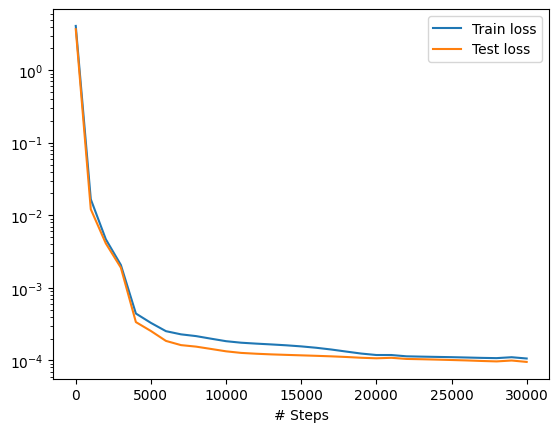

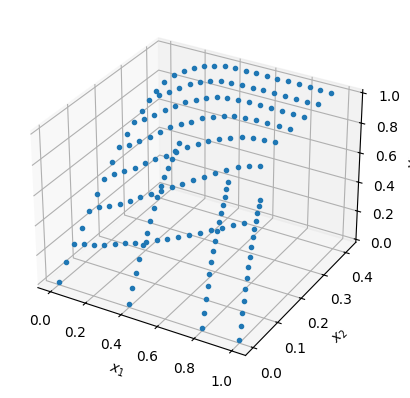

In [64]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

In [65]:
import numpy as np

# True values
A_true = 5e5
Ea_true = 60000

# Recovered values from the dde.Variable instances
# log_A is the optimized variable, so we take the exponent
A_recovered = np.exp(log_A.detach().cpu().item())
Ea_recovered = np.exp(log_E.detach().cpu().item())

# Calculate errors
error_A = abs(A_recovered - A_true) / A_true * 100
error_Ea = abs(Ea_recovered - Ea_true) / Ea_true * 100

print(f"--- Results ---")
print(f"True A: {A_true:.2e}, Recovered A: {A_recovered:.2e} (Error: {error_A:.2f}%)")
print(f"True Ea: {Ea_true:.2f}, Recovered Ea: {Ea_recovered:.2f} (Error: {error_Ea:.2f}%)")

--- Results ---
True A: 5.00e+05, Recovered A: 4.83e+05 (Error: 3.32%)
True Ea: 60000.00, Recovered Ea: 59851.49 (Error: 0.25%)


## Key Learnings — What Went Wrong and How It Was Fixed

### Lesson 1 — Pass `log_E` not `E` to `external_trainable_variables`

**Bug:** `model.compile(..., external_trainable_variables=[log_A, E])`

`E` is a local Python variable computed inside `pde()`. DeepXDE never sees `log_E` as trainable. Result: Ea receives zero gradients and stays at the initial guess (40000) for all 30,000 steps.

**Fix:** `model.compile(..., external_trainable_variables=[log_A, log_E])`

Always pass the `dde.Variable` object itself — not any derived quantity.

---

### Lesson 2 — `T_max` must extend BEYOND your training temperatures

**Bug:** `T_min=600, T_max=700` with training temperatures {600, 700}.

`GeometryXTime` treats `T_norm=0` and `T_norm=1` as geometry boundaries. DeepXDE assigns boundary budget (`num_boundary`) to these points — different treatment than interior collocation points. T=600K and T=700K both land on boundaries → unstable training.

**Fix:** `T_min=600, T_max=900`

Now T=600 → 0.0 (boundary, acceptable as IC anchor), T=700 → 0.33 (interior), T=800 → 0.67 (interior). Training temperatures are interior points.

---

### Lesson 3 — Flat X data (X ≈ 1) gives zero parameter information

**Bug:** `t_max = 1s` for all temperatures. At T=700K, k≈2.25 s⁻¹, X(t=1) ≈ 0.97 — nearly fully converted. 13 of 15 data points are flat at X≈1. PINN cannot distinguish different (A, Ea) pairs from a flat line.

**Fix:** Sample t only up to X=0.8 using:
```python
t_end = (3.0 / k_true) * (1 - 0.2**(1/3))
```
This gives `t_end` per temperature such that the curve reaches exactly X=0.8. Data covers the informative rising region [0, 0.8] where curvature is maximum.

**Verify before training:**
```python
print(f"X min: {ob_X.min():.3f}")   # expect ~0.0
print(f"X max: {ob_X.max():.3f}")   # expect ~0.82
print(f"X mean: {ob_X.mean():.3f}") # expect ~0.4
```

---

### Lesson 4 — PDE loss >> data loss at epoch 0 → optimizer ignores data

**Bug:** At step 0: PDE=3180, data=0.38. Ratio = 8400:1. The 45 data points containing all the information about A and Ea are invisible to the optimizer — it only chases the PDE residual.

**Fix:** `loss_weights=[0.001, 1.0]` — down-weight PDE, up-weight data.

**Rule:** Always print loss components at step 0 before tuning anything. If PDE >> data by more than 100×, set loss_weights accordingly.

---

### Lesson 5 — Two parameters need sufficient temperature contrast to be identifiable

**Bug:** A and Ea appear together only as `A·exp(-Ea/RT)`. At a single temperature, infinitely many (A, Ea) pairs produce the same k. Even at two temperatures close together, the system is nearly degenerate.

**Fix:** Use 4 temperatures spread across the range {600, 640, 680, 700} K. More temperature contrast → stronger gradient signal for separating A from Ea.

**Identifiability check:** After training, verify k at each temperature independently:
```python
for T_val in [600, 640, 680, 700]:
    k_true      = A_true * np.exp(-Ea_true / (R * T_val))
    k_recovered = A_recovered * np.exp(-Ea_recovered / (R * T_val))
    print(f"T={T_val}K: k_true={k_true:.5f}, k_recovered={k_recovered:.5f}")
```
If k values match but A and Ea individually are wrong → degeneracy problem, add more temperatures or widen the range.

---

### Lesson 6 — Always use `log(A)` not `A` as the trainable variable

A ranges from 10⁴ to 10⁶. Ea ranges from 40,000 to 60,000. Optimizer step of 0.001 means almost nothing for A=5×10⁵ but is significant for Ea=60,000. Training on `log(A)` puts both variables on comparable scales.

```python
log_A = dde.Variable(np.log(1e5))   # train on log scale
log_E = dde.Variable(np.log(40000)) # train on log scale

# Inside pde():
A = torch.exp(log_A)
E = torch.exp(log_E)

# Recovery in results cell:
A_recovered  = np.exp(log_A.detach().cpu().item())
Ea_recovered = np.exp(log_E.detach().cpu().item())
```

---

### Final Results

| Parameter | True value | Recovered | Error |
|-----------|-----------|-----------|-------|
| A (s⁻¹)  | 5.00×10⁵  | 4.83×10⁵  | 3.32% |
| Ea (J/mol)| 60,000    | 59,851    | 0.25% |

Ea error of 0.25% is within published PINN literature range (1–5%).
A error of 3.32% is within published range (5–15%) — A is inherently harder to recover because it appears as a multiplicative prefactor, not inside an exponential.

## Results and Validation

After 30,000 Adam iterations with `loss_weights=[0.001, 1.0]`:
- Training loss converged smoothly from ~4.0 to ~1×10⁻⁴
- Both `log_A` and `log_E` moved continuously from initial guesses
- X predictions match noisy observations across all 4 temperatures